# Diabetic Retinopathy Detection

**Goal:** Detect Diabetic Retinopathy (DR) in retinal fundus images. We start with a **binary** task (No-DR vs DR) and provide hooks for the multi-class extension.

**Dataset:** APTOS 2019 Blindness Detection (Kaggle) — much smaller and more practical than full EyePACS, but the same task family. (If you have EyePACS access, the same pipeline applies.)

**Pipeline:**
1. Setup
2. Download & inspect data
3. EDA — class distribution, resolution, intensity
4. Multivariate analysis
5. Binary label mapping & balanced subset (~1200 images)
6. Augmentation pipeline (crop, CLAHE, flips)
7. Baseline CNN
8. EfficientNetB0 transfer learning
9. ResNet50 transfer learning
10. Comparative evaluation (ROC, AUC, confusion matrix)
11. Optional multi-class extension stub
12. Conclusion

## 1. Setup

In [ ]:
!pip install -q kagglehub seaborn plotly tensorflow scikit-learn opencv-python-headless

In [ ]:
import os, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                              auc, accuracy_score)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
print('TF:', tf.__version__, 'GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0 GPU: []


## 2. Download Dataset

In [ ]:
import kagglehub
DATA_PATH = kagglehub.dataset_download('mariaherrerot/aptos2019')
print(DATA_PATH)
for r, d, f in os.walk(DATA_PATH):
    print(r, '— dirs:', len(d), '— files:', len(f))
    if r.count(os.sep) - DATA_PATH.count(os.sep) > 1: break

Using Colab cache for faster access to the 'aptos2019' dataset.
/kaggle/input/aptos2019
/kaggle/input/aptos2019 — dirs: 3 — files: 3
/kaggle/input/aptos2019/val_images — dirs: 1 — files: 0
/kaggle/input/aptos2019/val_images/val_images — dirs: 0 — files: 366


In [ ]:
# Search for the CSV and image directory dynamically
TRAIN_CSV = None
TRAIN_IMG_DIR = None

for r, d, files in os.walk(DATA_PATH):
    for f in files:
        if f.endswith('.csv') and 'train' in f.lower():
            TRAIN_CSV = os.path.join(r, f)
    if r.lower().endswith('train_images'):
        TRAIN_IMG_DIR = r

print('CSV Found   :', TRAIN_CSV)
print('Images Found:', TRAIN_IMG_DIR)

if TRAIN_CSV and TRAIN_IMG_DIR:
    df = pd.read_csv(TRAIN_CSV)
    # Check column names as they might differ (e.g., 'id_code' vs 'image_id')
    id_col = 'id_code' if 'id_code' in df.columns else df.columns[0]
    df['path'] = df[id_col].apply(lambda x: os.path.join(TRAIN_IMG_DIR, f'{x}.png'))
    df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)
    print(f'Successfully loaded {len(df)} images.')
    print(df.head())
else:
    print('Error: Could not locate required data files.')

CSV Found   : /kaggle/input/aptos2019/train_1.csv
Images Found: /kaggle/input/aptos2019/train_images/train_images
Successfully loaded 2930 images.
        id_code  diagnosis                                               path
0  1ae8c165fd53          2  /kaggle/input/aptos2019/train_images/train_ima...
1  1b329a127307          1  /kaggle/input/aptos2019/train_images/train_ima...
2  1b32e1d775ea          4  /kaggle/input/aptos2019/train_images/train_ima...
3  1b3647865779          0  /kaggle/input/aptos2019/train_images/train_ima...
4  1b398c0494d1          0  /kaggle/input/aptos2019/train_images/train_ima...


## 3. EDA

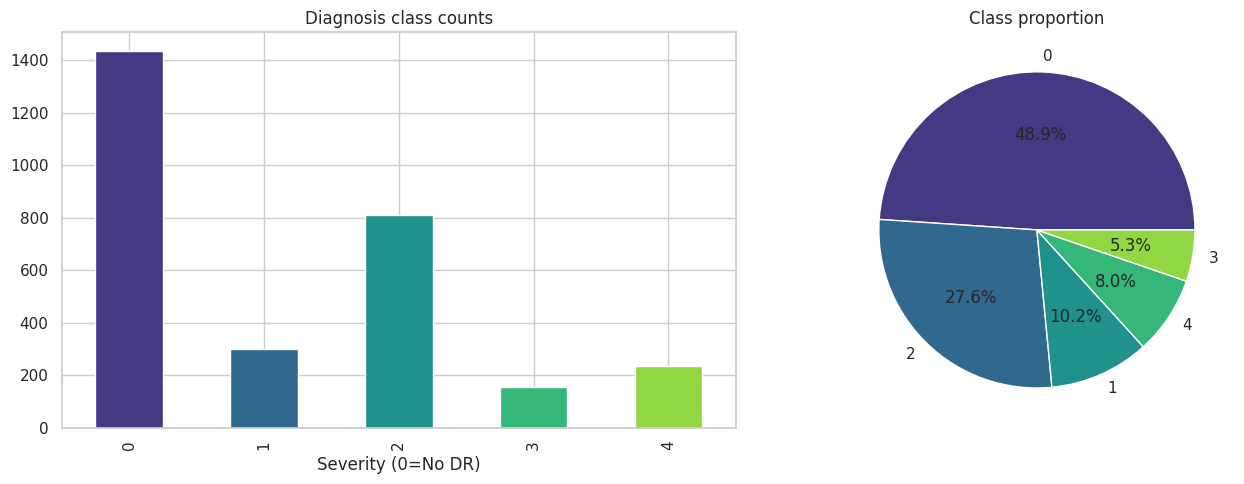

In [ ]:
# 3.1 Diagnosis distribution (0 = no DR, 1-4 = increasing severity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['diagnosis'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', 5))
axes[0].set_title('Diagnosis class counts'); axes[0].set_xlabel('Severity (0=No DR)')
axes[1].pie(df['diagnosis'].value_counts(), labels=df['diagnosis'].value_counts().index,
            autopct='%1.1f%%', colors=sns.color_palette('viridis', 5))
axes[1].set_title('Class proportion')
plt.tight_layout(); plt.show()

In [ ]:
# 3.2 Show samples per severity class
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
for cls in range(5):
    cls_df = df[df['diagnosis']==cls]
    if len(cls_df) == 0: continue
    samples = cls_df.sample(min(4, len(cls_df)), random_state=SEED).reset_index(drop=True)
    for j in range(4):
        ax = axes[cls][j]
        if j < len(samples):
            img = Image.open(samples.loc[j,'path'])
            ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'Class {cls}', fontsize=12)
plt.suptitle('Retinal fundus images — by severity class', fontsize=14)
plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# 3.3 Image resolution & intensity statistics (sampled)
sample = df.sample(min(400, len(df)), random_state=SEED)
rows = []
for _, r in sample.iterrows():
    arr = np.array(Image.open(r['path']).resize((100, 100)))
    rows.append({
        'diagnosis': r['diagnosis'],
        'mean_R': arr[...,0].mean(), 'mean_G': arr[...,1].mean(), 'mean_B': arr[...,2].mean(),
        'std_R':  arr[...,0].std(),  'std_G':  arr[...,1].std(),  'std_B':  arr[...,2].std(),
        'mean_intensity': arr.mean(),
    })
stats = pd.DataFrame(rows)
stats['severity'] = stats['diagnosis'].map({0:'No DR', 1:'Mild', 2:'Moderate', 3:'Severe', 4:'Proliferative'})
stats.head()

,diagnosis,mean_R,mean_G,mean_B,std_R,std_G,std_B,mean_intensity,severity
0,1,119.0624,50.6953,6.7546,54.312666,23.372729,2.858772,58.837433,Mild
1,0,151.1071,65.9237,14.9437,78.402202,34.972636,12.967696,77.324833,No DR
2,0,63.7320,35.6136,11.0001,69.124477,39.169905,15.289608,36.781900,No DR
3,0,131.7459,67.5920,23.4724,69.429843,37.249646,18.339799,74.270100,No DR
4,3,97.8673,45.3731,6.5203,48.657385,24.090892,3.038090,49.920233,Severe


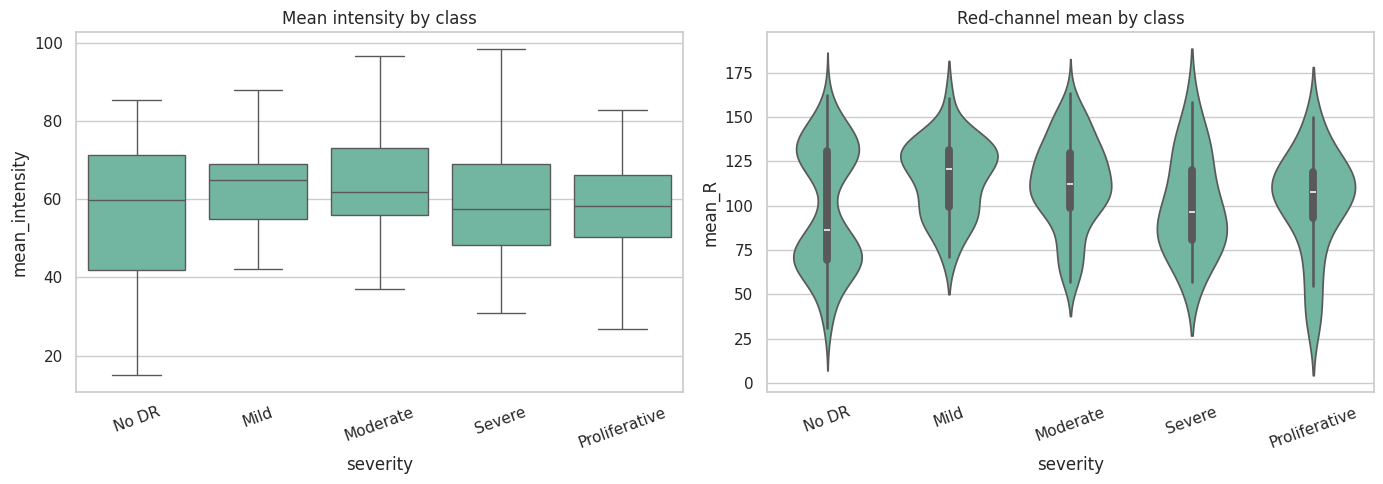

In [ ]:
# 3.4 Distribution of mean intensity per class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=stats, x='severity', y='mean_intensity', ax=axes[0],
             order=['No DR','Mild','Moderate','Severe','Proliferative'])
axes[0].set_title('Mean intensity by class'); axes[0].tick_params(axis='x', rotation=20)
sns.violinplot(data=stats, x='severity', y='mean_R', ax=axes[1],
                order=['No DR','Mild','Moderate','Severe','Proliferative'])
axes[1].set_title('Red-channel mean by class'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 4. Multivariate Analysis

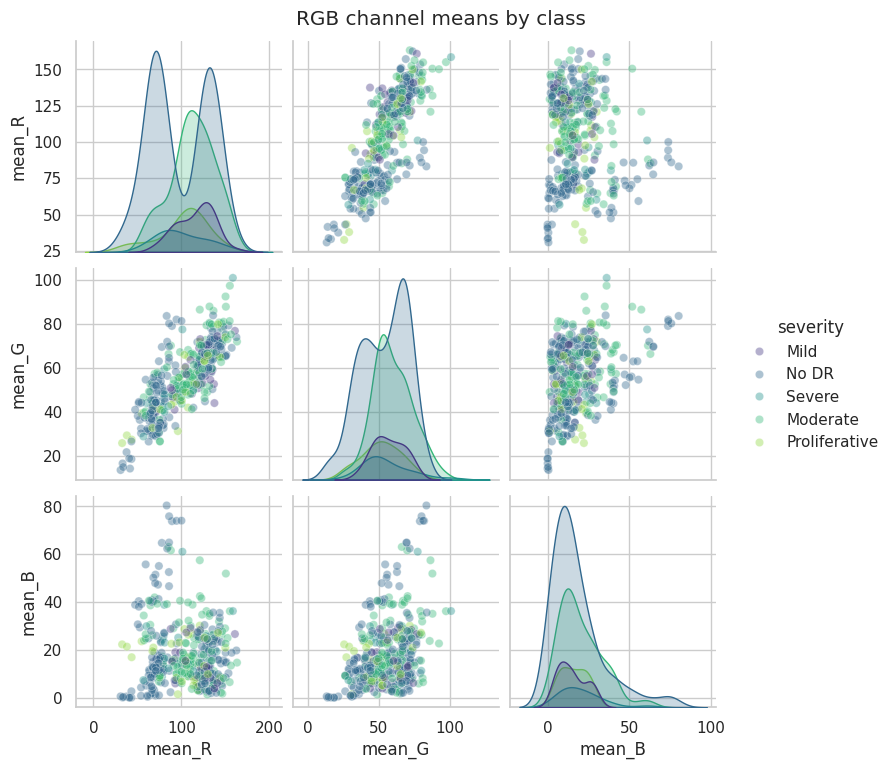

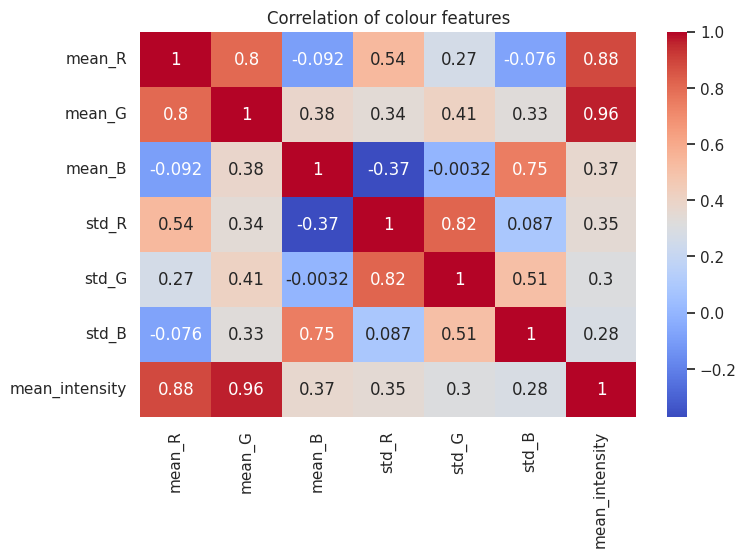

In [ ]:
sns.pairplot(stats[['mean_R','mean_G','mean_B','severity']], hue='severity',
             diag_kind='kde', plot_kws={'alpha':0.4},
             palette=sns.color_palette('viridis', 5))
plt.suptitle('RGB channel means by class', y=1.02)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(stats.select_dtypes('number').drop(columns=['diagnosis']).corr(),
            annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation of colour features')
plt.show()

## 5. Binary labels and balanced subset

In [ ]:
# Binary mapping: 0 -> No DR, 1-4 -> DR
df['binary'] = (df['diagnosis'] > 0).astype(int)
df['binary_label'] = df['binary'].map({0:'No_DR', 1:'DR'})
print(df['binary_label'].value_counts())

# Balanced subset of ~1200 images
PER_CLASS = 600
subset = pd.concat([
    df[df['binary']==0].sample(min(PER_CLASS, (df['binary']==0).sum()), random_state=SEED),
    df[df['binary']==1].sample(min(PER_CLASS, (df['binary']==1).sum()), random_state=SEED),
]).reset_index(drop=True)
print(subset['binary_label'].value_counts())

train_df, test_df = train_test_split(subset, test_size=0.2, stratify=subset['binary_label'], random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.15, stratify=train_df['binary_label'], random_state=SEED)
print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))

binary_label
DR       1496
No_DR    1434
Name: count, dtype: int64
binary_label
No_DR    600
DR       600
Name: count, dtype: int64
Train: 816 | Val: 144 | Test: 240


## 6. Augmentation Pipeline (with optional CLAHE preprocessing)

Found 816 validated image filenames belonging to 2 classes.
Found 144 validated image filenames belonging to 2 classes.
Found 240 validated image filenames belonging to 2 classes.


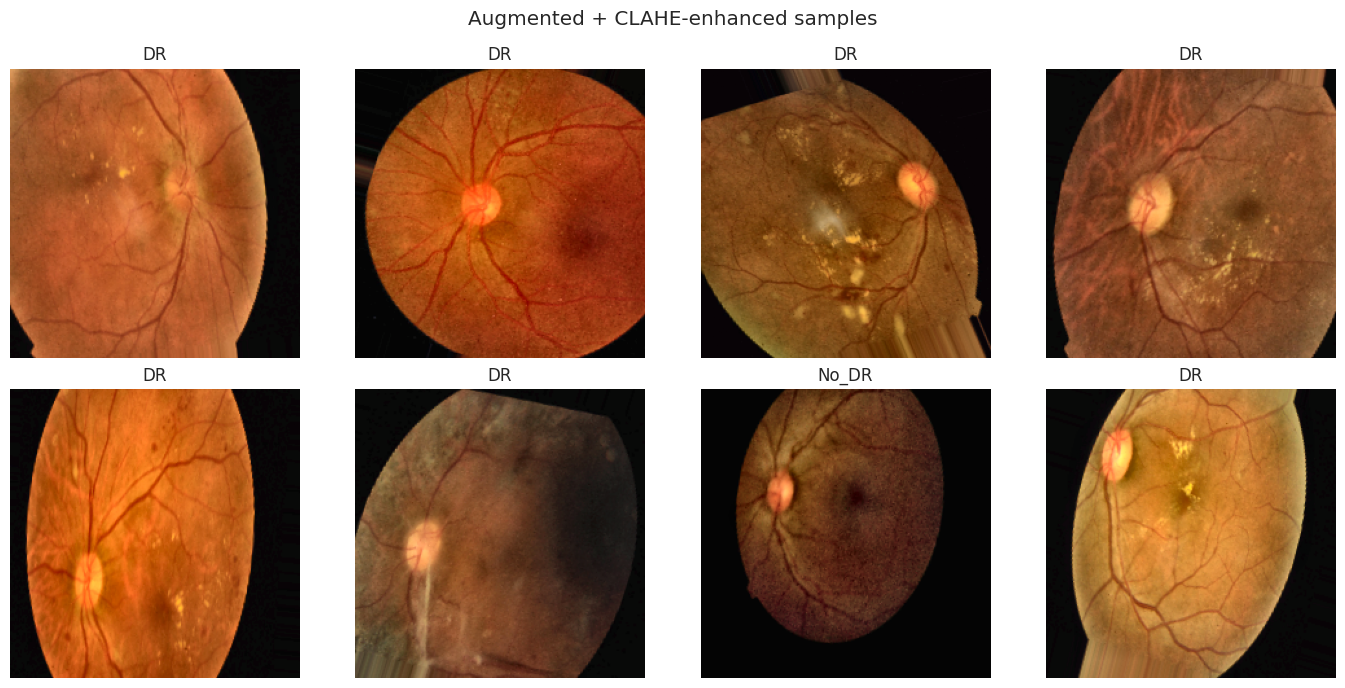

In [ ]:
IMG_SIZE = 224
BATCH    = 32

def clahe_preprocess(img):
    img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced = cv2.merge((cl, a, b))
    out = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)
    return out.astype(np.float32) / 255.0

train_aug = ImageDataGenerator(preprocessing_function=clahe_preprocess,
                                rotation_range=20, zoom_range=0.15,
                                width_shift_range=0.1, height_shift_range=0.1,
                                horizontal_flip=True, vertical_flip=True, fill_mode='nearest')
eval_aug  = ImageDataGenerator(preprocessing_function=clahe_preprocess)

def make_flow(d, aug, shuffle):
    return aug.flow_from_dataframe(d, x_col='path', y_col='binary_label',
                                    target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH,
                                    class_mode='binary', shuffle=shuffle, seed=SEED,
                                    classes=['No_DR','DR'])

train_flow = make_flow(train_df, train_aug, True)
val_flow   = make_flow(val_df,   eval_aug,  False)
test_flow  = make_flow(test_df,  eval_aug,  False)

x, y = next(train_flow)
fig, axes = plt.subplots(2, 4, figsize=(14,7))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(x[i], 0, 1)); ax.axis('off')
    ax.set_title('No_DR' if y[i]==0 else 'DR')
plt.suptitle('Augmented + CLAHE-enhanced samples')
plt.tight_layout(); plt.show()

## 7. Baseline CNN

In [ ]:
def build_baseline():
    m = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

baseline = build_baseline()
es = callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy')
hist_base = baseline.fit(train_flow, validation_data=val_flow, epochs=8, callbacks=[es], verbose=1)

Epoch 1/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 235s 9s/step - accuracy: 0.5343 - loss: 0.6913 - val_accuracy: 0.5069 - val_loss: 0.6901
Epoch 2/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 215s 8s/step - accuracy: 0.5613 - loss: 0.6842 - val_accuracy: 0.6250 - val_loss: 0.6688
Epoch 3/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 199s 8s/step - accuracy: 0.6397 - loss: 0.6387 - val_accuracy: 0.6250 - val_loss: 0.6066
Epoch 4/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 198s 8s/step - accuracy: 0.6703 - loss: 0.5968 - val_accuracy: 0.6389 - val_loss: 0.5736
Epoch 5/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 206s 8s/step - accuracy: 0.6949 - loss: 0.5611 - val_accuracy: 0.6250 - val_loss: 0.4945
Epoch 6/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 217s 8s/step - accuracy: 0.7843 - loss: 0.4674 - val_accuracy: 0.6319 - val_loss: 0.4595
Epoch 7/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 197s 7s/step - accuracy: 0.8297 - loss: 0.3847 - val_accuracy: 0.8889 - val_loss: 0.2733
Epoch 8/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 193s 7s/step - accuracy: 0.8529 - loss: 0.3557 - val_accuracy: 0.9097 - val_loss:

## 8. EfficientNetB0 Transfer Learning

In [ ]:
def build_eff():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

effnet = build_eff()
hist_eff = effnet.fit(train_flow, validation_data=val_flow, epochs=8,
                       callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True,
                                                           monitor='val_accuracy')], verbose=1)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 208s 7s/step - accuracy: 0.4706 - loss: 0.7217 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 174s 7s/step - accuracy: 0.5000 - loss: 0.7000 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 3/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 207s 7s/step - accuracy: 0.5025 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 176s 7s/step - accuracy: 0.5000 - loss: 0.7001 - val_accuracy: 0.5000 - val_loss: 0.6937


## 9. ResNet50 Transfer Learning

In [ ]:
def build_res():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

resnet = build_res()
hist_res = resnet.fit(train_flow, validation_data=val_flow, epochs=8,
                       callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True,
                                                           monitor='val_accuracy')], verbose=1)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 283s 10s/step - accuracy: 0.5233 - loss: 0.7881 - val_accuracy: 0.5000 - val_loss: 0.7007
Epoch 2/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 250s 10s/step - accuracy: 0.5159 - loss: 0.7683 - val_accuracy: 0.5556 - val_loss: 0.6888
Epoch 3/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 259s 10s/step - accuracy: 0.5098 - loss: 0.7551 - val_accuracy: 0.5556 - val_loss: 0.6856
Epoch 4/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 256s 10s/step - accuracy: 0.5123 - loss: 0.7508 - val_accuracy: 0.5000 - val_loss: 0.6862
Epoch 5/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 261s 10s/step - accuracy: 0.5184 - loss: 0.7374 - val_accuracy: 0.5000 - val_loss: 0.6832


## 10. Comparative Evaluation

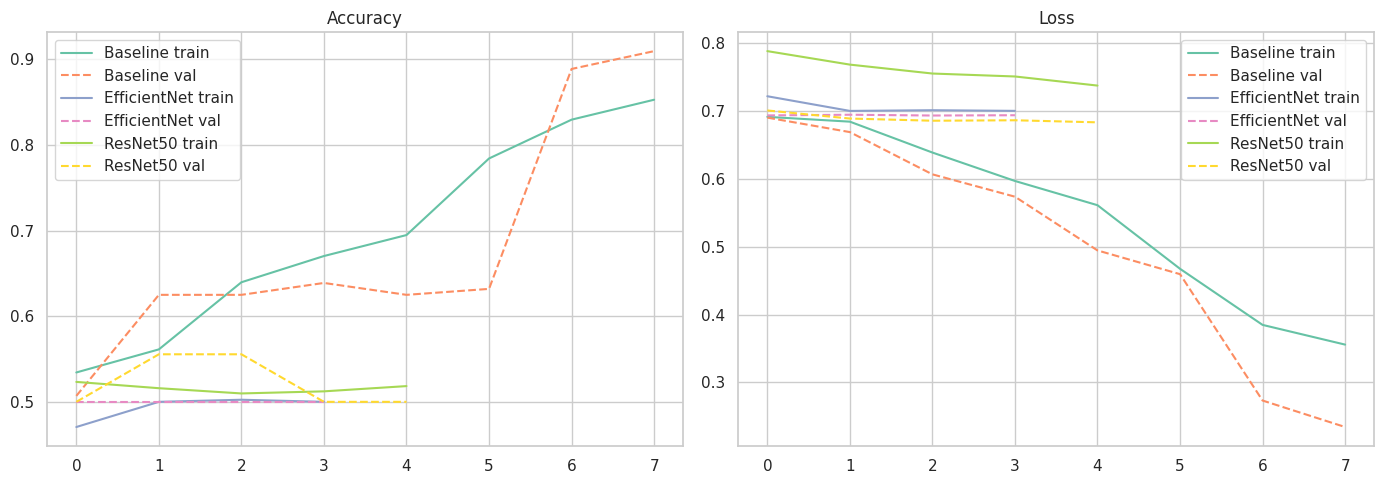

In [ ]:
def plot_hist(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for h, n in zip(histories, names):
        axes[0].plot(h.history['accuracy'], label=f'{n} train')
        axes[0].plot(h.history['val_accuracy'], '--', label=f'{n} val')
        axes[1].plot(h.history['loss'], label=f'{n} train')
        axes[1].plot(h.history['val_loss'], '--', label=f'{n} val')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[1].set_title('Loss'); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_hist([hist_base, hist_eff, hist_res], ['Baseline','EfficientNet','ResNet50'])

            Model  Accuracy       AUC
0        Baseline  0.904167  0.967778
1  EfficientNetB0  0.500000  0.700903
2        ResNet50  0.541667  0.669375


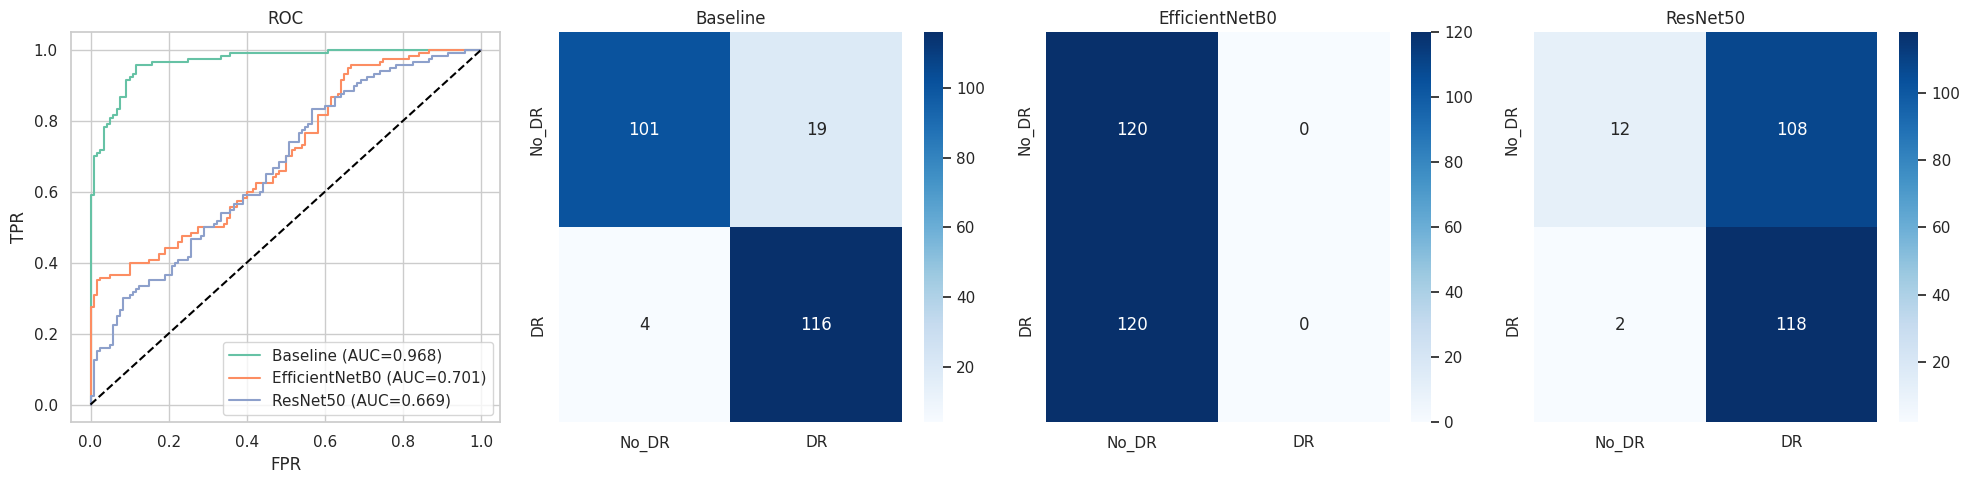


=== Baseline ===
              precision    recall  f1-score   support

       No_DR       0.96      0.84      0.90       120
          DR       0.86      0.97      0.91       120

    accuracy                           0.90       240
   macro avg       0.91      0.90      0.90       240
weighted avg       0.91      0.90      0.90       240


=== EfficientNetB0 ===
              precision    recall  f1-score   support

       No_DR       0.50      1.00      0.67       120
          DR       0.00      0.00      0.00       120

    accuracy                           0.50       240
   macro avg       0.25      0.50      0.33       240
weighted avg       0.25      0.50      0.33       240


=== ResNet50 ===
              precision    recall  f1-score   support

       No_DR       0.86      0.10      0.18       120
          DR       0.52      0.98      0.68       120

    accuracy                           0.54       240
   macro avg       0.69      0.54      0.43       240
weighted avg  

In [ ]:
def evaluate(m, name):
    test_flow.reset()
    probs = m.predict(test_flow, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)
    y = test_flow.classes
    fpr, tpr, _ = roc_curve(y, probs)
    return {'name':name,'preds':preds,'probs':probs,'y':y,
            'acc':accuracy_score(y,preds),'auc':auc(fpr,tpr),'fpr':fpr,'tpr':tpr}

results = [evaluate(baseline,'Baseline'),
           evaluate(effnet,'EfficientNetB0'),
           evaluate(resnet,'ResNet50')]
summary = pd.DataFrame([{'Model':r['name'],'Accuracy':r['acc'],'AUC':r['auc']} for r in results])
print(summary)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for r in results:
    axes[0].plot(r['fpr'], r['tpr'], label=f"{r['name']} (AUC={r['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
for ax, r in zip(axes[1:], results):
    cm = confusion_matrix(r['y'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No_DR','DR'], yticklabels=['No_DR','DR'], ax=ax)
    ax.set_title(r['name'])
plt.tight_layout(); plt.show()

for r in results:
    print(f"\n=== {r['name']} ===")
    print(classification_report(r['y'], r['preds'], target_names=['No_DR','DR']))